# Exploratory Data Analysis

Dataset: **Bank Marketing**

This notebook corresponds to **Section 3.3 "Exploratory Data Analysis"** of the paper.
It loads the cleaned dataset (`bank-cleaned.csv`) and inspects the distribution
of the target variable and of all numerical / categorical features.

Figure 2a of the paper (target distribution) is generated by the second
plotting cell below.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
ROOT = Path.cwd().resolve()                 # BankMarketing/notebooks
DATA_RAW = ROOT.parent / "data" / "raw"
FIG_DIR = ROOT.parent / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
data = pd.read_csv(DATA_RAW / "bank-full.csv", sep=';')
print("Shape:", data.shape)


Shape: (45211, 17)


In [3]:
# Style configuration for matplotlib and seaborn
plt.style.use('ggplot')
sns.set_context("notebook", font_scale=1.1)

# Define color palette
colors = ["#0b4e9e", "#ffc203"]  # Blue and Yellow
sns.set_palette(colors)

# Column definitions
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
categorical_columns = [col for col in categorical_columns if col != 'y']  # Exclude target variable

C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3098532445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y', data=data, palette=colors)


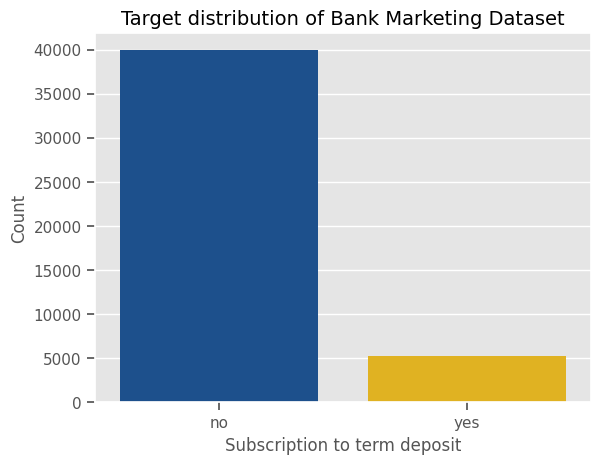

In [4]:
# Visualization of the target variable 'y' distribution
ax = sns.countplot(x='y', data=data, palette=colors)
plt.title("Target distribution of Bank Marketing Dataset", fontsize=14)
plt.xlabel("Subscription to term deposit", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()


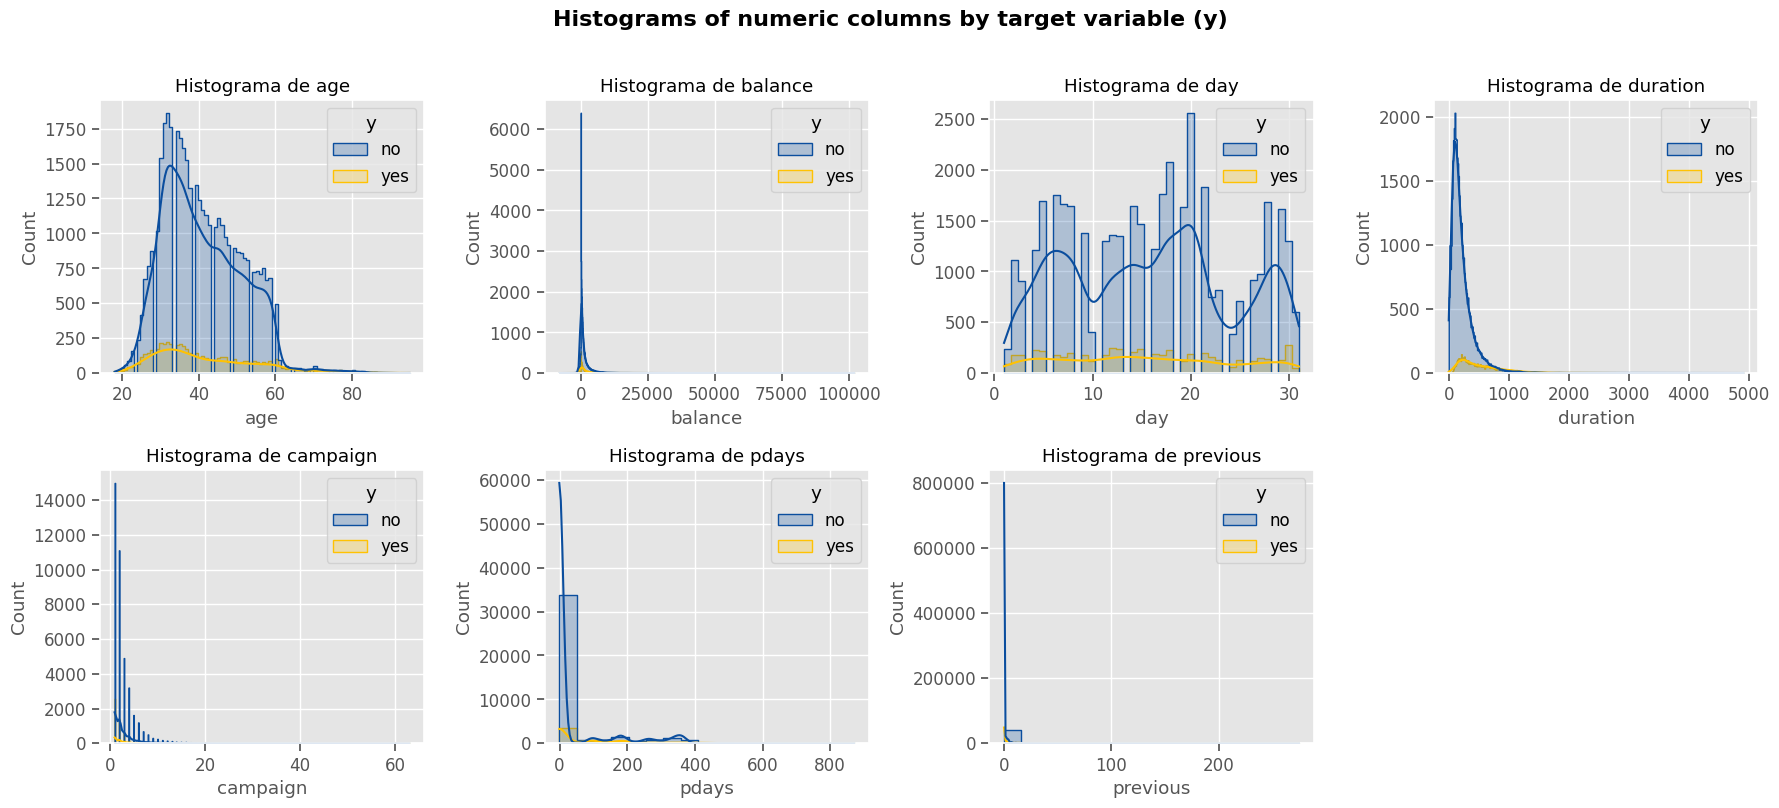

In [5]:
# Histograms segmented by the target variable (y)
fig, axs = plt.subplots(nrows=(len(numeric_columns) + 2) // 4, ncols=4, figsize=(18, 8))
fig.suptitle("Histograms of numeric columns by target variable (y)", fontsize=16, weight="bold", y=1.01)

for i, col in enumerate(numeric_columns):
    row, col_pos = divmod(i, 4)
    sns.histplot(data, x=col, hue='y', element='step', kde=True, ax=axs[row, col_pos])
    axs[row, col_pos].set_title(f'Histograma de {col}')

# Remove empty subplots
for j in range(i + 1, len(axs.flatten())):
    fig.delaxes(axs.flatten()[j])

plt.tight_layout()
plt.show()


C:\Users\danie\AppData\Local\Temp\ipykernel_28444\2910685501.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_28444\2910685501.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_28444\2910685501.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
C:\Users\danie\AppD

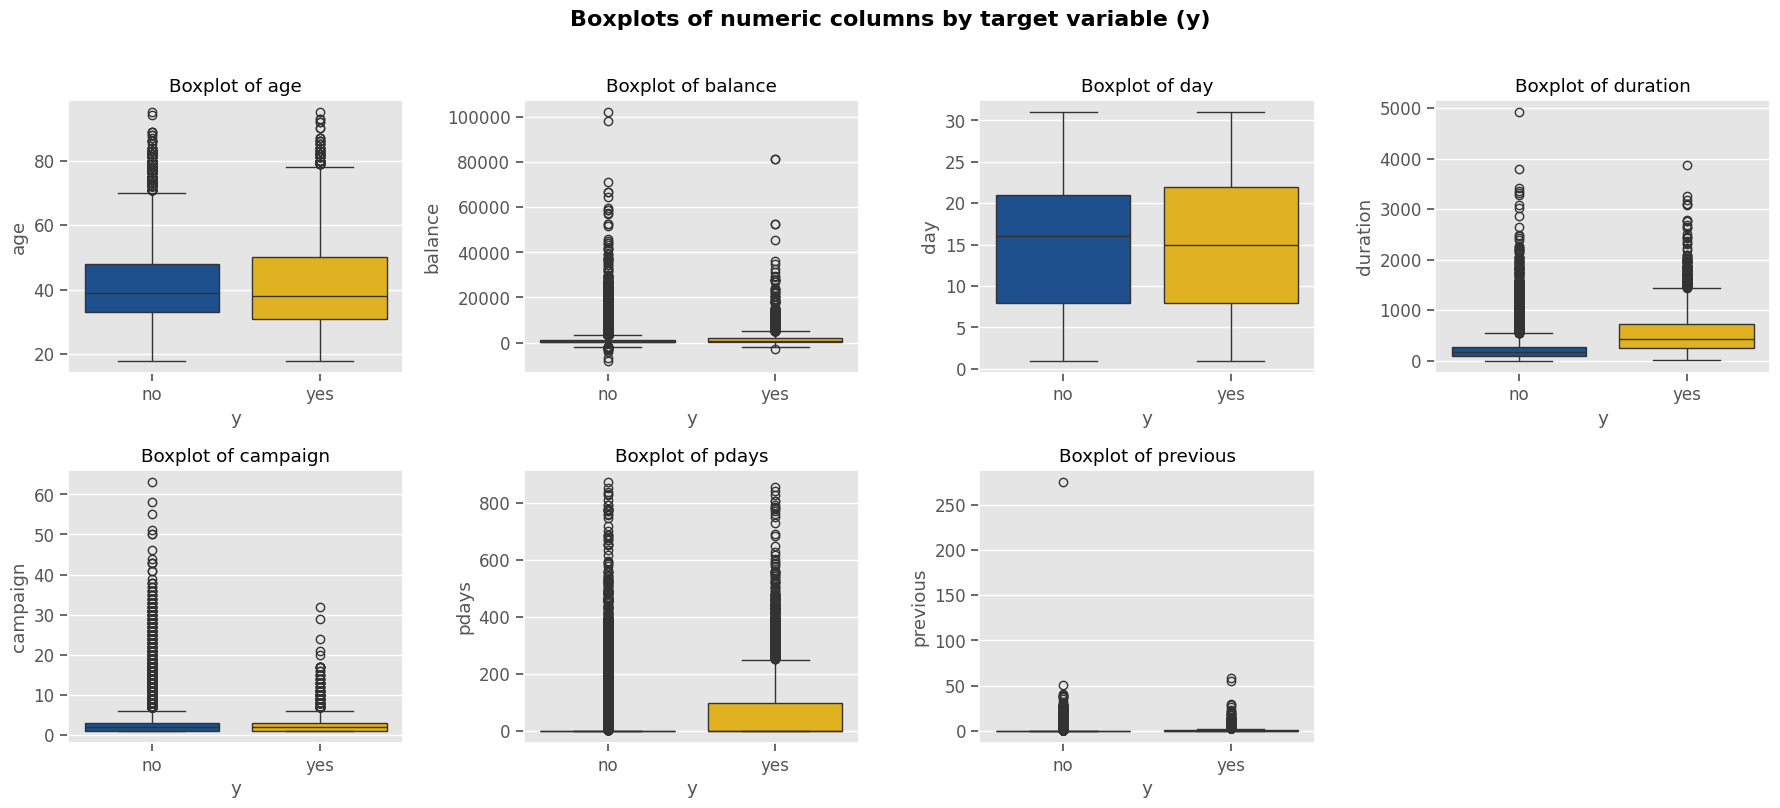

In [6]:
# Boxplots by target variable (y)
fig, axs = plt.subplots(nrows=(len(numeric_columns) + 2) // 4, ncols=4, figsize=(18, 8))
fig.suptitle("Boxplots of numeric columns by target variable (y)", fontsize=16, weight="bold", y=1.01)

for i, col in enumerate(numeric_columns):
    row, col_pos = divmod(i, 4)
    sns.boxplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
    axs[row, col_pos].set_title(f'Boxplot of {col}')

# Remove empty subplots
for j in range(i + 1, len(axs.flatten())):
    fig.delaxes(axs.flatten()[j])

plt.tight_layout()
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3176700090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3176700090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3176700090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
C:\User

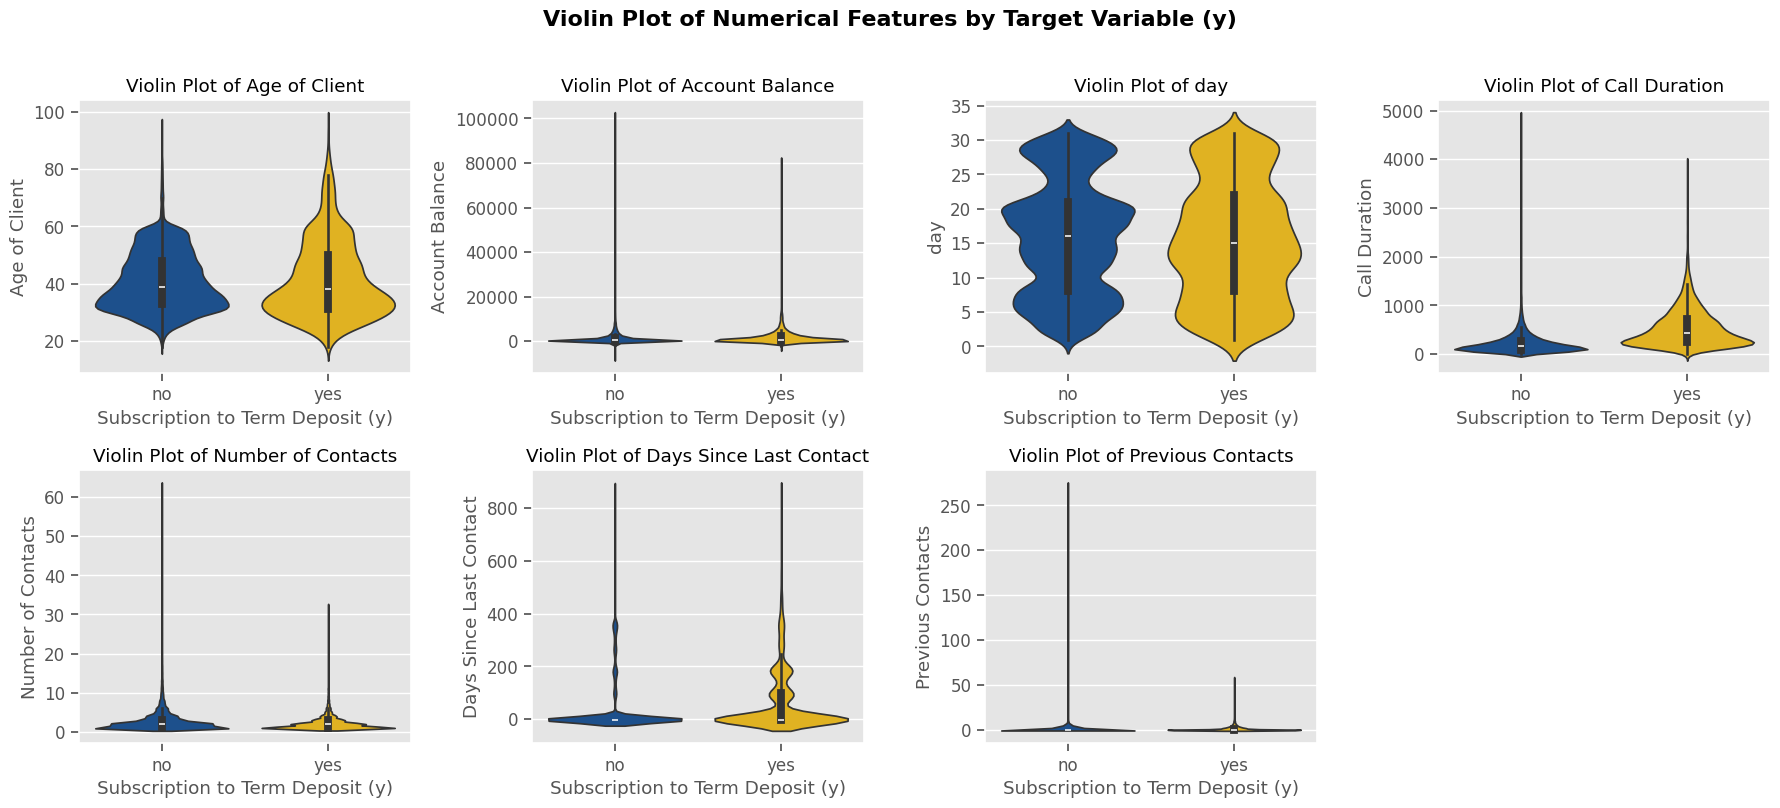

In [7]:
numeric_labels = {
    'age': 'Age of Client',
    'balance': 'Account Balance',
    'duration': 'Call Duration',
    'campaign': 'Number of Contacts',
    'pdays': 'Days Since Last Contact',
    'previous': 'Previous Contacts'
}
    
fig, axs = plt.subplots(nrows=(len(numeric_columns) + 2) // 4, ncols=4, figsize=(18, 8))
fig.suptitle("Violin Plot of Numerical Features by Target Variable (y)", fontsize=16, weight="bold", y=1.01)

for i, col in enumerate(numeric_columns):
    row, col_pos = divmod(i, 4)
    sns.violinplot(x='y', y=col, data=data, ax=axs[row, col_pos], palette=colors)
    axs[row, col_pos].set_title(f'Violin Plot of {numeric_labels.get(col, col)}')
    axs[row, col_pos].set_xlabel('Subscription to Term Deposit (y)')
    axs[row, col_pos].set_ylabel(numeric_labels.get(col, col))

# Remove empty subplots
for j in range(i + 1, len(axs.flatten())):
    fig.delaxes(axs.flatten()[j])

plt.tight_layout()
plt.show()


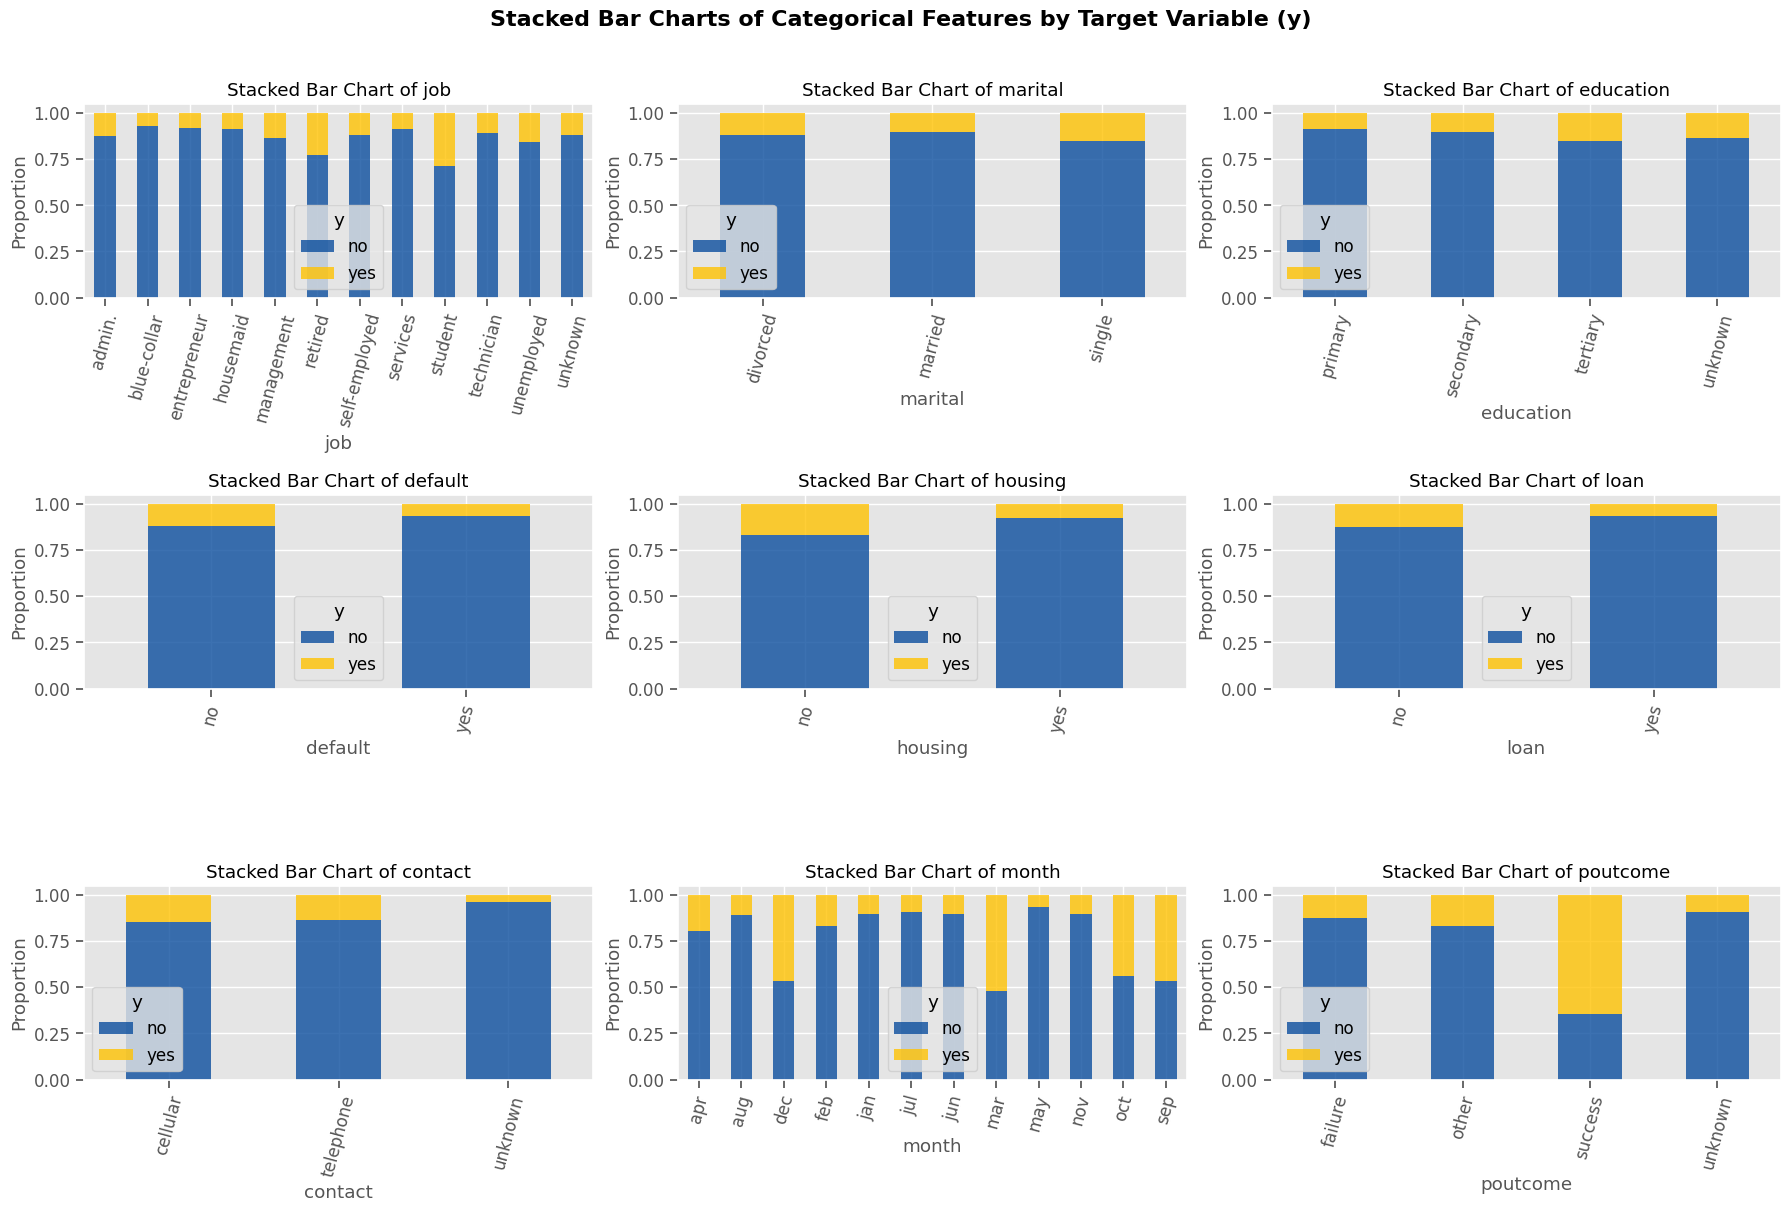

In [8]:
# Stacked Bar Charts for categorical variables
fig, axs = plt.subplots(nrows=(len(categorical_columns) + 2) // 3, ncols=3, figsize=(18, 12))
fig.suptitle("Stacked Bar Charts of Categorical Features by Target Variable (y)", fontsize=16, weight="bold", y=1.01)

for i, col in enumerate(categorical_columns):
    row, col_pos = divmod(i, 3)
    cross_tab = pd.crosstab(data[col], data['y'], normalize="index")
    cross_tab.plot(kind='bar', stacked=True, ax=axs[row, col_pos], color=colors, alpha=0.8)
    axs[row, col_pos].set_title(f'Stacked Bar Chart of {col}')
    axs[row, col_pos].set_xlabel(col)
    axs[row, col_pos].set_ylabel("Proportion")
    axs[row, col_pos].tick_params(axis='x', rotation=75)

# Remove empty subplots
for j in range(i + 1, len(axs.flatten())):
    fig.delaxes(axs.flatten()[j])

plt.tight_layout()
plt.show()

### Numerical feature correlations


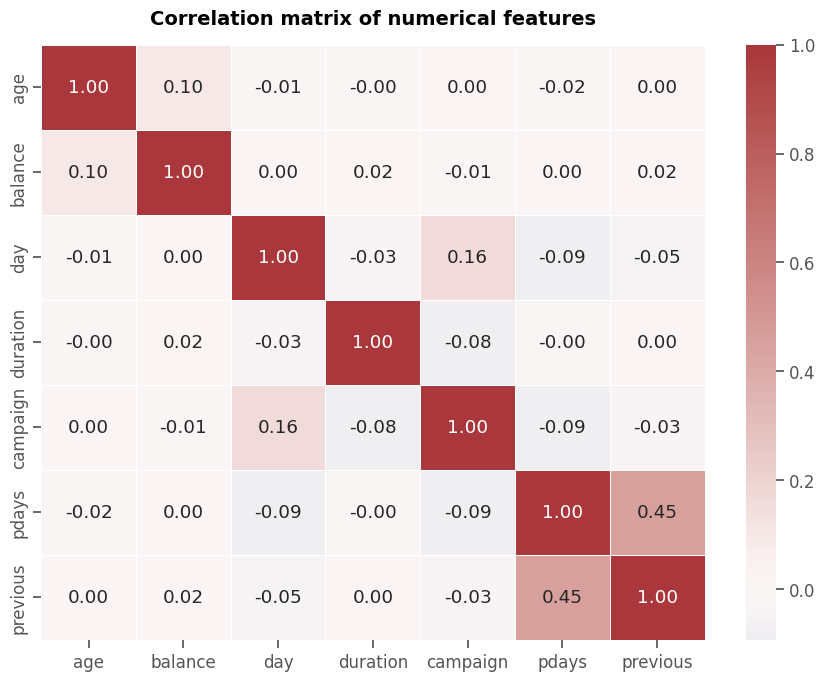

In [9]:
# Pearson correlation among numerical features
correlations = data[numeric_columns].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=ax,
    linewidths=0.5
    )
ax.set_title("Correlation matrix of numerical features", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


Text(0.5, 1.02, 'Correlation of numerical features with target variable (y)')

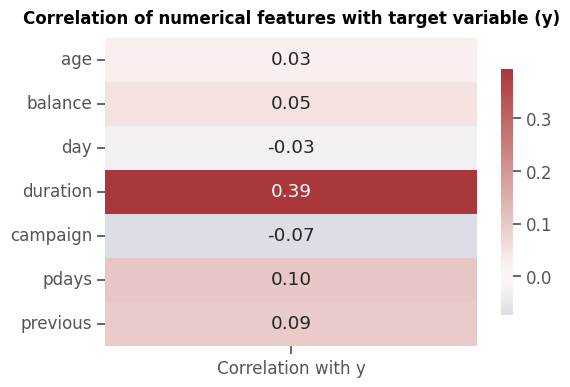

In [10]:
# Pearson correlation between numerical features and the target variable 'y' heatmap
data['y_binary'] = data['y'].map({'yes': 1, 'no': 0})
correlations_with_target = data[numeric_columns + ['y_binary']].corr()['y_binary'].drop('y_binary')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    correlations_with_target.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    cbar_kws={"shrink": 0.8},
    ax=ax,
    xticklabels=['Correlation with y']
)
ax.set_title("Correlation of numerical features with target variable (y)", fontsize=12, weight="bold", y=1.02)

### Subscription rate by selected categorical features


C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3493531111.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=axs[i], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3493531111.py:11: UserWarning: 
The palette list has fewer values (2) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=rate.index, y=rate.values, ax=axs[i], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3493531111.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=axs[i], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_28444\3493531111.py:11: UserWarning: 
The palett

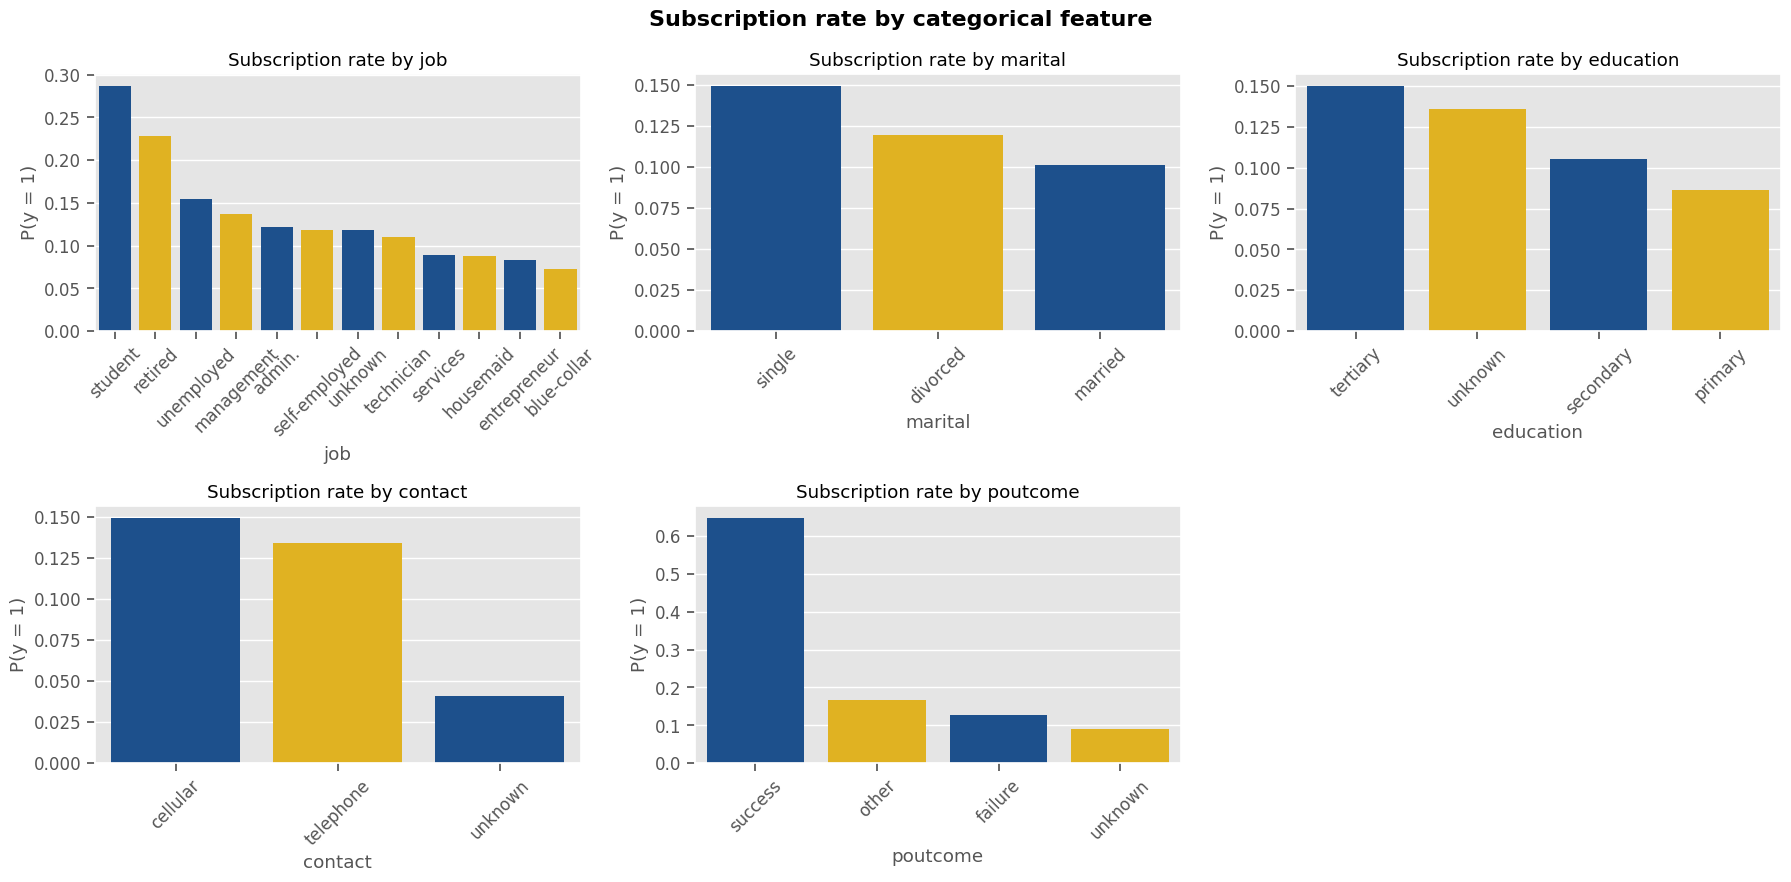

In [11]:
# Subscription rate (proportion of y=1) per category, for the most informative
# categorical variables. Higher bars indicate categories with stronger conversion.
selected_categoricals = ["job", "marital", "education", "contact", "poutcome"]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle("Subscription rate by categorical feature", fontsize=16, weight="bold")
axs = axs.flatten()

for i, col in enumerate(selected_categoricals):
    rate = data.groupby(col)["y_binary"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=axs[i], palette=colors)
    axs[i].set_title(f"Subscription rate by {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("P(y = 1)")
    axs[i].tick_params(axis="x", rotation=45)

# Remove the unused subplot
for j in range(len(selected_categoricals), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


### Call duration distribution by outcome


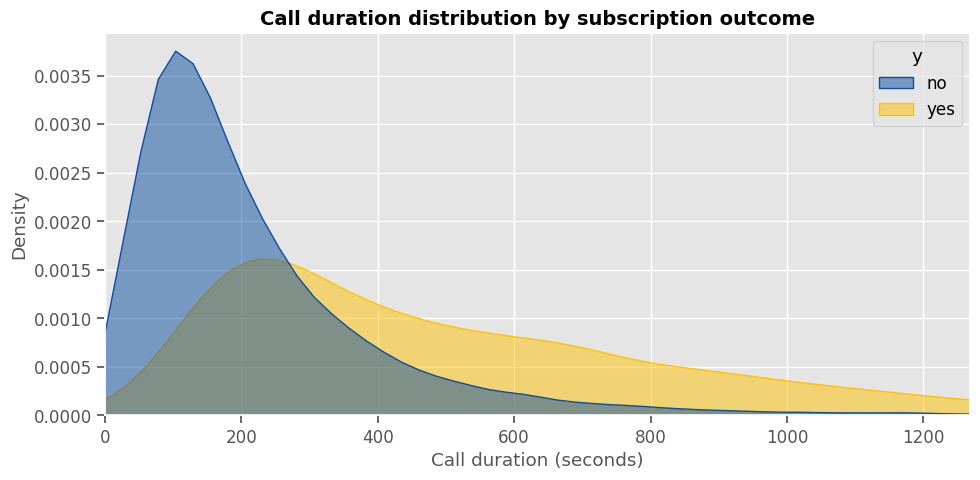

In [12]:
# Duration of the last contact is one of the strongest predictors of subscription.
# We compare its distribution between the two outcome classes.
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=data, x="duration", hue="y", fill=True, common_norm=False,
    palette=colors, alpha=0.5, ax=ax,
)
ax.set_xlim(0, data["duration"].quantile(0.99))
ax.set_title("Call duration distribution by subscription outcome",
             fontsize=14, weight="bold")
ax.set_xlabel("Call duration (seconds)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()
